![logo](https://climate.copernicus.eu/sites/default/files/2025-03/logoline_c3s.png)

# Analysis of September 2020 European heatwave using ERA5 climate reanalysis data from C3S

**This notebook can be run on free online platforms, such as Binder, Kaggle and Colab, or they can be accessed from GitHub. The links to run this notebook in these environments are provided here, but please note they are not supported by ECMWF.**

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/c3s-training-submodule-reanalysis/main?labpath=reanalysis-heatwave.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/c3s-training-submodule-reanalysis/blob/main/reanalysis-heatwave.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/c3s-training-submodule-reanalysis/blob/main/reanalysis-heatwave.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/c3s-training-submodule-reanalysis/blob/main/reanalysis-heatwave.ipynb)

![logo](./img/Temp_records_banner.png)

## Learning objectives 🎯

In September 2020, a record-breaking heatwave occured in large parts of western Europe, ([see a description here](https://climate.copernicus.eu/september-brings-record-breaking-warm-temperatures-and-low-sea-ice)). The city of Lille in northern France for example experienced its hottest day in September 2020 since records began in 1945. In this tutorial we will analyse this event with data from the Climate Data Store (CDS) of the Copernicus Climate Change Service (C3S).

In this tutorial, we will:

- View daily maximum 2m temperature for September 2020
- Compare maximum temperatures with climatology

## Prepare your environment

### Install earthkit and cdsapi

We will request data from the Climate Data Store (CDS) with the help of [earthkit](https://earthkit-data.readthedocs.io/en/latest/).

The code below will ensure that the `earthkit` and `cdsapi` packages are installed.  earthkit-data's `cds` source uses the `cdsapi` package under the hood to talk to the CDS, so `cdsapi` needs to be installed too, even though we never import or call it directly.

In [ ]:
%pip install -q earthkit cdsapi

### (Install and) Import libraries

In [1]:
import numpy as np

# earthkit for searching, retrieving and loading CDS data
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit.utils.units.convert import convert_units
from earthkit import transforms as ekt

# Disable warnings for data download via API
import urllib3
urllib3.disable_warnings()


## Explore data

To search for data, visit the CDS website: https://cds.climate.copernicus.eu. Here you can search for ERA5 data using the search bar. The data we need for this tutorial is the [ERA5 hourly data on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). Specifically, we are going to use reanalysis data on single levels from 1979 to present. To facilitate your search you can use keywords, or apply various filters.


### Search for the data

Having selected the correct dataset, we now need to specify what product type, variables, temporal and geographic coverage we are interested in. These can all be selected in the **"Download data"** tab. In this tab a form appears in which we will select the following parameters to download. We will choose a subset area of 1x1 degrees, corresponding to a region of around 111km North/South and 72km East/West in Belgium and Northern France, around the city of Lille:

:::{dropdown} Parameters of data to download

- Product type: `Reanalysis`
- Variable: `2m temperature`
- Year: `all`
- Month: `September`
- Day: `all`
- Time: `all`
- Geographical area: `North: 51`, `East: 4`, `South: 50`, `West: 3`
- Format: `NetCDF`

:::


At the end of the download forms, select "Show API request". This will reveal a block of code, which you can simply copy and paste into a cell of your Jupyter Notebook (see cell below). Having copied the API request into the cell below, running this will retrieve and download the data you requested into your local directory.

:::{warning}

Please remember to accept the terms and conditions of the dataset, at the bottom of the CDS download form!

:::

### Download the data

With the API request copied into the cell below, running this cell will retrieve and download the data you requested into your local directory.


If you have not set up your .cdsapirc file, you will be prompted for your CDS credentials when executing the download cell. See [how to api](https://cds.climate.copernicus.eu/how-to-api) for details on how to set up your .cdsapirc file.

In [2]:
source = 'cds'
dataset = 'reanalysis-era5-single-levels'
request = {
    'product_type': 'reanalysis',
    'data_format': 'netcdf',
    'variable': '2m_temperature',
    'year': [
        '1979', '1980', '1981',
        '1982', '1983', '1984',
        '1985', '1986', '1987',
        '1988', '1989', '1990',
        '1991', '1992', '1993',
        '1994', '1995', '1996',
        '1997', '1998', '1999',
        '2000', '2001', '2002',
        '2003', '2004', '2005',
        '2006', '2007', '2008',
        '2009', '2010', '2011',
        '2012', '2013', '2014',
        '2015', '2016', '2017',
        '2018', '2019', '2020',
    ],
    'month': '09',
    'day': [
        '01', '02', '03',
        '04', '05', '06',
        '07', '08', '09',
        '10', '11', '12',
        '13', '14', '15',
        '16', '17', '18',
        '19', '20', '21',
        '22', '23', '24',
        '25', '26', '27',
        '28', '29', '30',
    ],
    'time': [
        '00:00', '01:00', '02:00',
        '03:00', '04:00', '05:00',
        '06:00', '07:00', '08:00',
        '09:00', '10:00', '11:00',
        '12:00', '13:00', '14:00',
        '15:00', '16:00', '17:00',
        '18:00', '19:00', '20:00',
        '21:00', '22:00', '23:00',
    ],
    'area': [
        51, 3, 50,
        4,
    ],
    # This request covers 42 years x 30 days x 24 hours, which CDS rejects
    # as a single job (too large). 'split_on' tells earthkit-data to break
    # it into several smaller requests instead of one - here, batches of 21
    # years each, giving exactly two requests (1979-1999, 2000-2020). Each
    # batch is downloaded separately (in parallel when possible), and
    # earthkit-data merges the results back together automatically, so
    # data.to_xarray() below still returns a single combined Dataset - no
    # manual concatenation needed.
    'split_on': {'year': 21},
}

data = ekd.from_source(source, dataset, request)


  0%|          | 0/2 [00:00<?, ?it/s]

2026-09-24 10:16:14,407 INFO Request ID is b013bf98-a129-48ac-86c4-a98b38174fcf
2026-09-24 10:16:14,499 INFO status has been updated to successful
2026-09-24 10:16:15,358 INFO Request ID is 6c5fe468-fd00-4114-9762-e1c918cd458f
2026-09-24 10:16:15,545 INFO status has been updated to successful


fd8680dfbcf87693140e22edeffede4.nc:   0%|          | 0.00/1.60M [00:00<?, ?B/s]

a9130d4998ad13777f2c65cc55d5bf7c.nc:   0%|          | 0.00/1.60M [00:00<?, ?B/s]

### Inspect data

We have requested the data in NetCDF format. This is a commonly used format for array-oriented scientific data. `earthkit.data.from_source()` returns a [FieldList](https://earthkit-data.readthedocs.io/en/latest/guide/data_format/fieldlist.html)-like object which already knows how to describe itself and convert straight to an [xarray.Dataset](https://xarray.pydata.org/en/stable/generated/xarray.Dataset.html) via `.to_xarray()`.


In [3]:
# Convert directly to an Xarray Dataset
ds = data.to_xarray()

Now we can query our newly created Xarray dataset ...

In [4]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 30240, latitude: 5, longitude: 5)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 242kB 1979-09-01 ... 2020-09-30T2...
    expver      (valid_time) <U4 484kB dask.array<chunksize=(15120,), meta=np.ndarray>
  * latitude    (latitude) float64 40B 51.0 50.75 50.5 50.25 50.0
  * longitude   (longitude) float64 40B 3.0 3.25 3.5 3.75 4.0
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(15120, 5, 5), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-22T11:51 GRIB to CDM+CF via cfgrib-0.9.1...

We see that the dataset has one variable called **"t2m"**, which stands for "2 metre temperature", and three coordinates of **longitude**, **latitude** and **time**.

Select the icons to the right of the table above to expand the attributes of the coordinates and data variables. What are the units of the temperature data?

While an Xarray **dataset** may contain multiple variables, an Xarray **data array** holds a single variable (which may still be multi-dimensional) and its coordinates. To make the processing of the **t2m** data easier, we convert in into an Xarray data array:

In [5]:
da = ds['t2m']

Let's convert the units of the 2m temperature data from Kelvin to degrees Celsius. The formula for this is simple: degrees Celsius = Kelvin - 273.15

In [6]:
t2m_C = convert_units(da,'degC','K')

## View daily maximum 2m temperature for September 2020

As a next step, let us visualize the daily maximum 2m air temperature for September 2020. From the graph, we should be able to identify which day in September was hottest in the area around Lille.

First we average over the subset area:

:::{note}

The size covered by each data point varies as a function of latitude. We need to take this into account when averaging. One way to do this is to use Earthkit's `spatial.reduce` function.

:::

In [7]:
Lille_t2m = ekt.spatial.reduce(t2m_C, how='mean', weights='latitude')

Now we can calculate the max daily 2m temeprature for each day in September 2020:

In [8]:
Lille_2020_max = ekt.climatology.daily_max(Lille_t2m, climatology_range=('2020-09-01','2020-09-30'))

Let's plot the results in a chart:

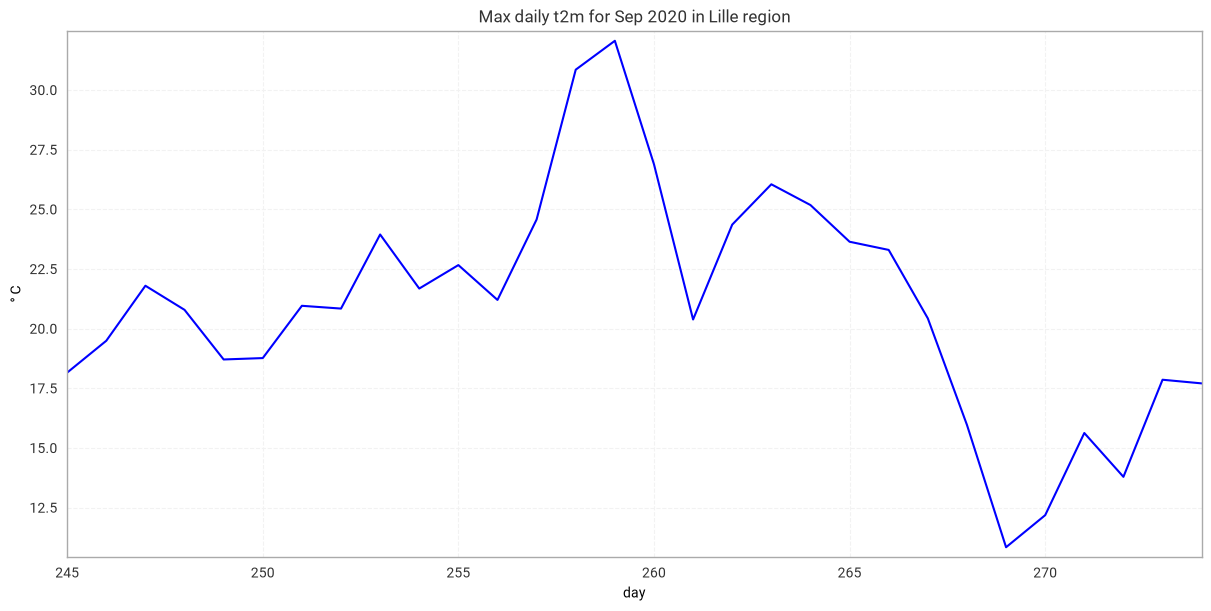

In [9]:
ts = ekp.TimeSeries(figsize=(12, 6))
ts.line(Lille_2020_max, color='blue')
ts.title('Max daily t2m for Sep 2020 in Lille region')
ts.ylabel('° C')
ts.xlabel('day')
ts.ax.grid(linestyle='--')
ts.show()

In [10]:
print('The maximum temperature in September 2020 in this area was', 
      np.around(Lille_2020_max.max().values, 1), 'degrees Celsius.')

The maximum temperature in September 2020 in this area was 32.1 degrees Celsius.


Which day in September had the highest maximum temperature?

Is this typical for Northern France? How does this compare with the long term average? We will seek to answer these questions in the next section.

## Compare maximum temperatures with climatology
We will now seek to discover just how high the temperature for Lille in mid September 2020 was when compared with typical values exptected in this region at this time of year. To do that we will calculate the climatology of maximum daily 2m temperature for each day in September for the period of 1979 to 2019, and compare these with our values for 2020.

First, we calculate the maximum daily value for each day in the time series:

In [11]:
Lille_max = ekt.temporal.daily_max(Lille_t2m)

Now we calculate the climatology for this data. We will calculate three quantiles of the maximum daily 2m temperatures for the 40 year time series for each day in September:

In [12]:
Lille_max.load() #Loading the data into memory lo allow Earthkit to compute the median

Lille_max_max = ekt.climatology.daily_max(Lille_max, climatology_range=('1979-01-01','2019-12-31'))
Lille_max_min = ekt.climatology.daily_min(Lille_max, climatology_range=('1979','2019'))
Lille_max_mid = ekt.climatology.daily_median(Lille_max, climatology_range=('1979-01-01','2019-12-31'))

Let's plot this data. We will plot the, maximum, minimum and 50th quantile of the maximum daily temperature to have an idea of the expected range in this part of France in September, and compare this range with the values for 2020:

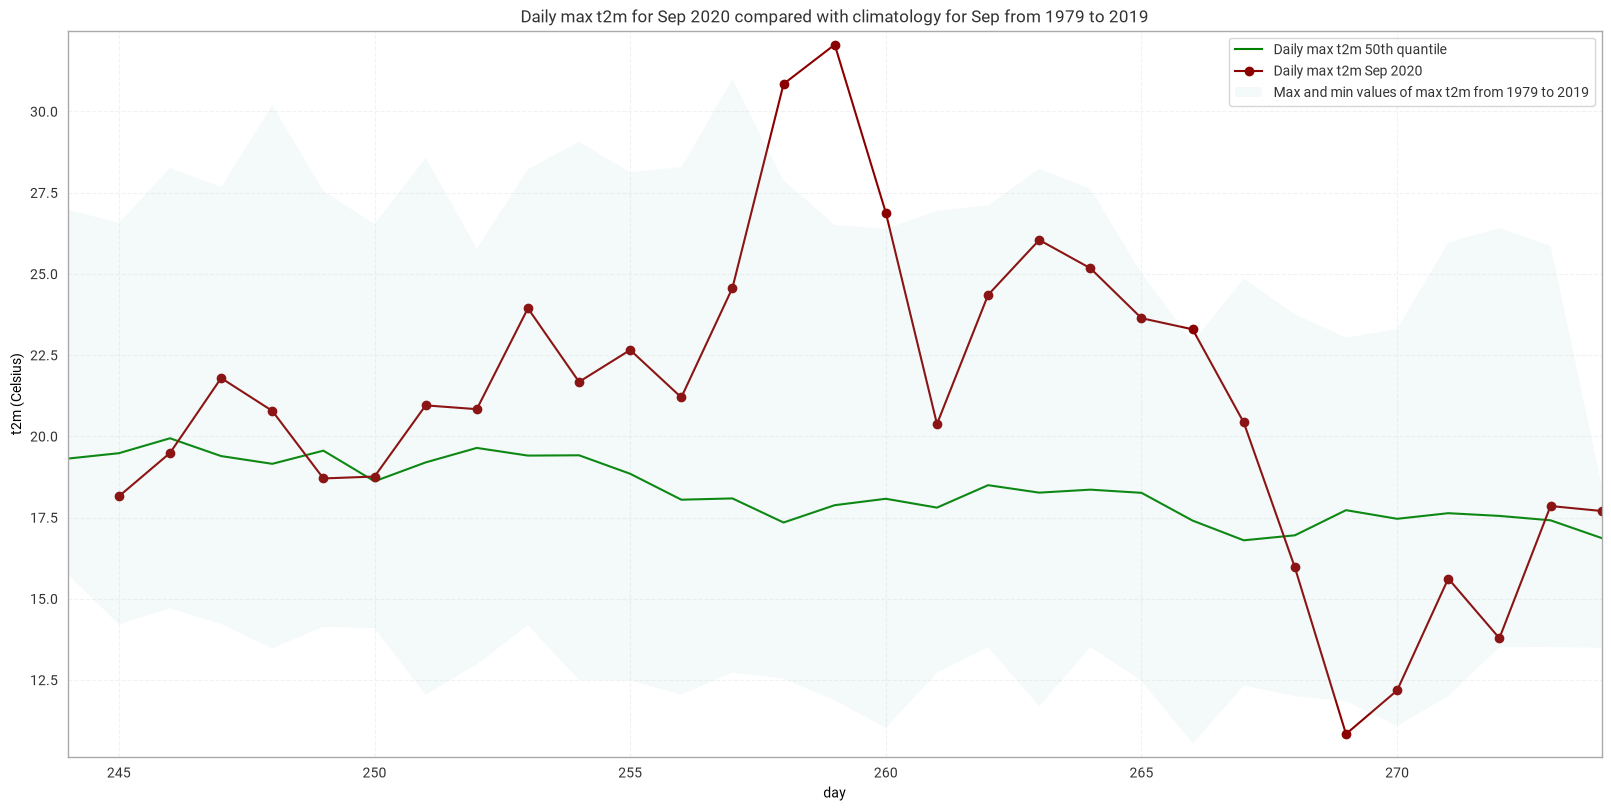

In [13]:
ts = ekp.TimeSeries(figsize=(16, 8))

ts.line(Lille_max_mid, color='green', label='Daily max t2m 50th quantile')
ts.line(Lille_2020_max, marker='o', linestyle='-', color='darkred', label='Daily max t2m Sep 2020')
ts.fill_between(Lille_max_max, Lille_max_min, alpha=0.1,
                label='Max and min values of max t2m from 1979 to 2019')

#ts.ax.set_xlim(1, 30)
#ts.ax.set_ylim(10, 33)
ts.title('Daily max t2m for Sep 2020 compared with climatology for Sep from 1979 to 2019')
ts.ylabel('t2m (Celsius)')
ts.xlabel('day')
ts.legend()
ts.ax.grid(linestyle='--')

ts.show()


Interestingly, we see from this plot that while the temperatures from 14 to 16 Sep 2020 were the highest in the ERA5 dataset, on 25 September 2020, the lowest of the maximum temperatures was recorded for this dataset.

We will now look more closely at the probability distribution of maximum temperatures for 15 September in this time period. To do this, we will first select only the max daily temperature for 15 September, for each year in the time series:

In [14]:
Lille_max = Lille_max.dropna('valid_time', how='all')
Lille_max_1979_2019 = Lille_max.sel(valid_time=slice("1979","2019"))
Lille_15 = Lille_max_1979_2019[14::30]

We will then plot the histogram of this:

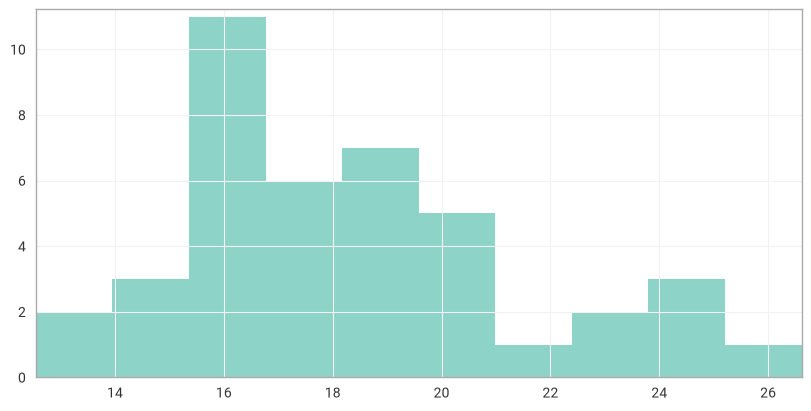

In [15]:
fig = ekp.TimeSeries()
fig.ax.hist(Lille_15,bins=10)

fig.show()

Look at the range of maximum temperatures for 15 September in the period from 1979 to 2019. Has the temperature in this period ever exceeded that of 15 September 2020?

The histogram shows the distribution of maximum temperature of one day in each year of the time series, which corresponds to 41 samples. In order to increase the number of samples, let's plot the histogram of maximum temperatures on 15 September, plus or minus three days. This would increase our number of samples by a factor of seven.

To do this, we first need to produce an index that takes the maximum 2m air temperature values from 12 to 18 September (15 September +/- three days) from every year in the time series. The first step is to initiate three numpy arrays:
* `years`: with the number of years [0:40]
* `days_in_sep`: index values of day range [11:17]
* `index`: empty numpy array with 287 (41 years * 7) entries


In [16]:
years = np.arange(41)
days_in_sep = np.arange(11,18)
index = np.zeros(287)

In a next step, we then loop through each entry of the `years` array and fill the empty `index` array year by year with the correct indices of the day ranges for each year. The resulting array contains the index values of interest.

In [17]:
for i in years:
    index[i*7:(i*7)+7] = days_in_sep + (i*30)
index = index.astype(int)

We then apply this index to filter the array of max daily temperature from 1979 to 2019. The resulting object is an array of values representing the maximum 2m air temperature in Lille between 12 and 18 September for each year from 1979 to 2019:

In [18]:
Lille_7days = Lille_max.values[index]

Now we can plot the histogram of maximum daily temperatures in the days 12-18 September from 1979-2019:

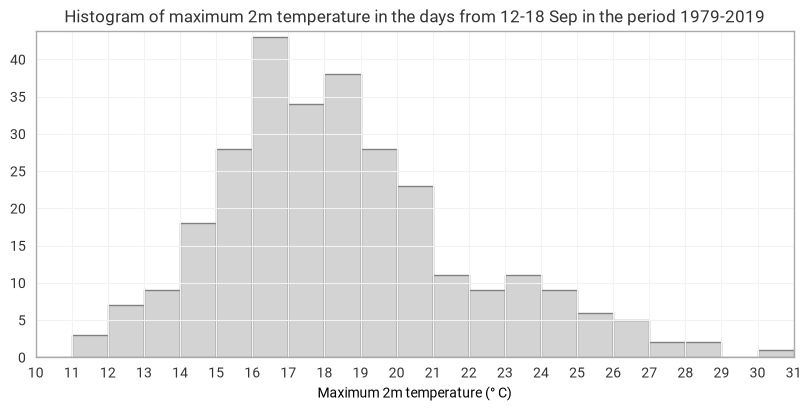

In [19]:
fig = ekp.TimeSeries()
fig.ax.hist(Lille_7days, bins = np.arange(10,32,1), color='lightgrey', ec='grey')
fig.title('Histogram of maximum 2m temperature in the days from 12-18 Sep in the period 1979-2019')
fig.xticks(frequency=1)
fig.ylabel('Accumulated days')
fig.xlabel('Maximum 2m temperature (° C)')
fig.show()

In the histogram above, you see that even if we take an increased sample covering a wider temporal range, the maximum daily temperature still never reached that of 15 September 2020. To increase the sample even further, you could include data from a longer time period. The C3S reanalysis dataset now extends back to 1940 and is accessible here [ERA5 hourly data on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets?q=era5+hourly+single+levels).

## Take home messages 📌

- By comparing the climatology with the daily maximum values, one can easily identify the days in which maximum temperatures were higher than the usual, and also the days in which they were lower.

- A useful way of understanding how unnusual were the values of a heatwave is by looking at a histogram of maximum temperatures in the climatology.